# NanoVer Path

## Setup client

In [1]:
from nanover.websocket import NanoverImdClient
from path_controls import show_controls

try:
    client.close()
except:
    pass

client = NanoverImdClient.from_discovery(server_name="DEMO-gluhut")
show_controls(client)

interactive(children=(IntSlider(value=1000, description='Force', max=5000, min=100, step=100), Output()), _dom…

interactive(children=(FloatSlider(value=0.1, description='Speed', max=0.1, step=0.01), Output()), _dom_classes…

interactive(children=(FloatSlider(value=0.0, description='Range', max=1.0), Output()), _dom_classes=('widget-i…

# Setup reference particles

In [2]:
client.set_shared_value("suggested.reference.particles", [[2, 3, 4, 7, 24, 27], [46, 47, 50, 55, 58, 79], [63, 64, 65, 70, 71, 72]])
# client.remove_shared_value("suggested.reference.particles")

## Extracting lines

In [3]:
state = client.copy_state()
paths = [(key, value) for (key, value) in state.items() if key.endswith("reference")]
trails = [(key, value) for (key, value) in state.items() if key.endswith("trail")]

for id, path in paths:
    print(f"{id} with {len(path)} points")
for id, trail in trails:
    print(f"{id} with {len(trail)} points")

## Plotting lines

In [4]:
import matplotlib.pyplot as plt
%matplotlib widget

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for id, line in [*paths, *trails]:
    x, y, z = zip(*line)
    ax.plot(x, y, z, label=id)

ax.legend()
plt.show()

RuntimeError: 'widget is not a recognised GUI loop or backend name

In [ ]:
import MDAnalysis as mda
from nanover.trajectory import FrameData
from nanover.mdanalysis.converter import frame_data_to_mdanalysis

u = frame_data_to_mdanalysis(client.current_frame)

def analyse_dist(frame: FrameData):
    u.atoms.positions = frame.particle_positions
    return u.select_atoms('resname 0GB').positions[0][0]

In [61]:
print(analyse_dist(client.current_frame))

2.7790437


In [34]:
client.frames
[analyse_dist(frame) for frame in client.frames]

TypeError: Universe.empty() missing 1 required positional argument: 'n_atoms'

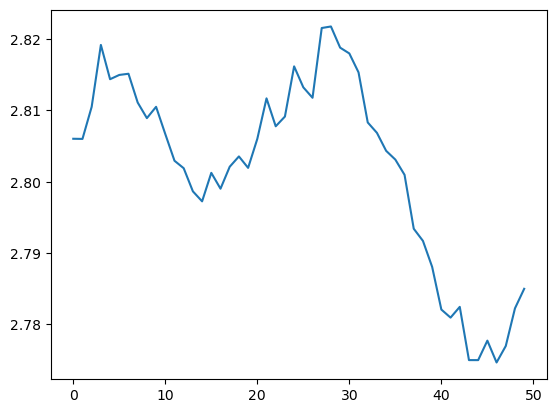

In [ ]:
from nanover.trajectory.convert import unpack_dict_frame
from matplotlib.animation import FuncAnimation
#

x_pos = []
for frame in client.frames:
    frame = FrameData(unpack_dict_frame(frame.frame_dict))
    current = client.current_frame.copy()
    current.update(frame)
    x_pos.append(analyse_dist(current))
plt.plot(x_pos)

C:\Users\IRL-santiago-4\AppData\Local\Temp\ipykernel_26464\634822727.py:28: UserWarning: frames=None which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.
  anim = FuncAnimation(fig, update, frames = None)


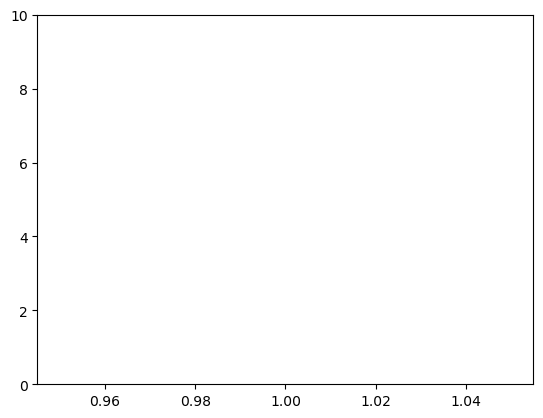

In [77]:
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import random

# initial data
x = [1]
y = [random.randint(1,10)]

# creating the first plot and frame
fig, ax = plt.subplots()
graph = ax.plot(x,y,color = 'g')[0]
plt.ylim(0,10)


# updates the data and graph
def update(frame):
    global graph

    # updating the data
    x.append(x[-1] + 1)
    y.append(random.randint(1,10))

    # creating a new graph or updating the graph
    graph.set_xdata(x)
    graph.set_ydata(y)
    plt.xlim(x[0], x[-1])

anim = FuncAnimation(fig, update, frames = None)
plt.show()

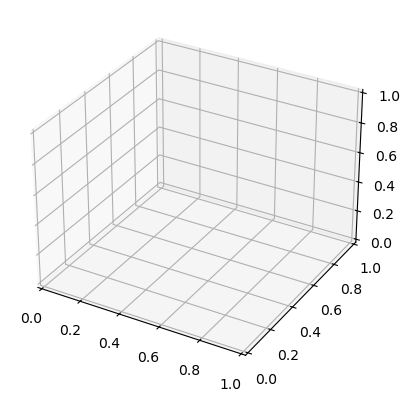

In [47]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

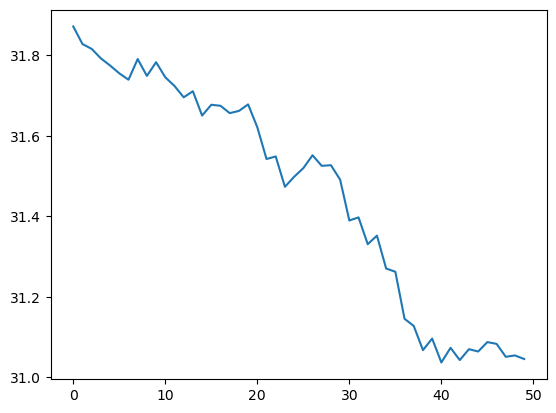

In [48]:
plt.plot(x_pos)